# Round1 Descriptive Statistics

Goal:
- Provide a single notebook for quick data sanity checks before baseline training.
- Keep all team members aligned on core dataset statistics.

This notebook reports:
- News table sizes and missingness.
- Behavior/impression-level statistics.
- Candidate-level statistics after impression expansion.
- Label and category distributions.

Outputs are saved to `round1_baselines/round1_descriptive_stats_output/`.


In [5]:
# Setup: imports, paths, and reproducibility
from __future__ import annotations

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find project root from {start}. Expected a parent containing 'data'."
    )

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = find_project_root(NOTEBOOK_DIR)

TRAIN_NEWS_PATH = PROJECT_ROOT / "data/train/news.tsv"
VALID_NEWS_PATH = PROJECT_ROOT / "data/valid/news.tsv"
TRAIN_BEHAVIORS_PATH = PROJECT_ROOT / "data/train/behaviors.tsv"
VALID_BEHAVIORS_PATH = PROJECT_ROOT / "data/valid/behaviors.tsv"
OUTPUT_DIR = NOTEBOOK_DIR / "round1_descriptive_stats_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for required_path in [
    TRAIN_NEWS_PATH, VALID_NEWS_PATH, TRAIN_BEHAVIORS_PATH, VALID_BEHAVIORS_PATH
]:
    if not required_path.exists():
        raise FileNotFoundError(f"Missing required file: {required_path}")

print("Project root:", PROJECT_ROOT.resolve())
print("Output directory:", OUTPUT_DIR.resolve())
print("Seed:", SEED)


Project root: /Users/xiangningdeng/Desktop/2026 UCLA MDSH-Submit
Output directory: /Users/xiangningdeng/Desktop/2026 UCLA MDSH-Submit/round1_baselines/round1_descriptive_stats_output
Seed: 42


## 1) Load Data

We load both train/valid `news.tsv` and `behaviors.tsv`, then compute first-pass size checks.


In [6]:
NEWS_COLS = [
    "news_id", "category", "subcategory", "title", "abstract", "url",
    "title_entities", "abstract_entities"
]
BEHAVIORS_COLS = ["impression_id", "user_id", "time", "history", "impressions"]

news_train = pd.read_csv(TRAIN_NEWS_PATH, sep="\t", header=None, names=NEWS_COLS, dtype=str)
news_valid = pd.read_csv(VALID_NEWS_PATH, sep="\t", header=None, names=NEWS_COLS, dtype=str)
beh_train = pd.read_csv(TRAIN_BEHAVIORS_PATH, sep="\t", header=None, names=BEHAVIORS_COLS, dtype=str)
beh_valid = pd.read_csv(VALID_BEHAVIORS_PATH, sep="\t", header=None, names=BEHAVIORS_COLS, dtype=str)

news_all = pd.concat([news_train, news_valid], ignore_index=True).drop_duplicates("news_id")

shape_summary = pd.DataFrame([
    {"table": "news_train", "rows": len(news_train), "cols": news_train.shape[1]},
    {"table": "news_valid", "rows": len(news_valid), "cols": news_valid.shape[1]},
    {"table": "news_combined_unique", "rows": len(news_all), "cols": news_all.shape[1]},
    {"table": "behaviors_train", "rows": len(beh_train), "cols": beh_train.shape[1]},
    {"table": "behaviors_valid", "rows": len(beh_valid), "cols": beh_valid.shape[1]},
])

shape_summary


,table,rows,cols
0,news_train,51282,8
1,news_valid,42416,8
2,news_combined_unique,65238,8
3,behaviors_train,156965,5
4,behaviors_valid,73152,5


### Interpretation for Section 1 (Load Data)

- The split sizes are consistent and suitable for baseline comparison (`156,965` train impressions vs `73,152` valid impressions).
- After merging train/valid news and removing duplicates, the corpus contains `65,238` unique news items.
- The schema is stable across splits (`news`: 8 columns, `behaviors`: 5 columns), reducing preprocessing mismatch risk.

## 2) Candidate-Level And Label Statistics

Expand impressions to candidate rows to align with round1 ranking metrics.


In [7]:
def parse_impressions(impressions: str):
    if not isinstance(impressions, str) or not impressions.strip():
        return []
    pairs = []
    for token in impressions.strip().split():
        if "-" not in token:
            continue
        news_id, label = token.rsplit("-", 1)
        try:
            pairs.append((news_id, int(label)))
        except ValueError:
            continue
    return pairs

def history_len(history: str) -> int:
    if not isinstance(history, str) or not history.strip():
        return 0
    return len(history.strip().split())

def expand_candidates(beh_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, row in beh_df.iterrows():
        pairs = parse_impressions(row["impressions"])
        for pos, (news_id, label) in enumerate(pairs):
            rows.append({
                "impression_id": str(row["impression_id"]),
                "user_id": str(row["user_id"]),
                "candidate_news_id": str(news_id),
                "label": int(label),
                "candidate_pos": int(pos),
            })
    return pd.DataFrame(rows)

train_candidates = expand_candidates(beh_train)
valid_candidates = expand_candidates(beh_valid)

candidate_summary = pd.DataFrame([
    {
        "split": "train",
        "impressions": len(beh_train),
        "candidates": len(train_candidates),
        "avg_candidates_per_impression": len(train_candidates) / len(beh_train),
        "ctr": train_candidates["label"].mean(),
    },
    {
        "split": "valid",
        "impressions": len(beh_valid),
        "candidates": len(valid_candidates),
        "avg_candidates_per_impression": len(valid_candidates) / len(beh_valid),
        "ctr": valid_candidates["label"].mean(),
    },
])

candidate_summary


,split,impressions,candidates,avg_candidates_per_impression,ctr
0,train,156965,5843444,37.227688,0.040446
1,valid,73152,2740998,37.469898,0.040636


### Interpretation for Section 2 (Candidate-Level Statistics)

- Expanding impressions yields `5,843,444` train candidates and `2,740,998` valid candidates, which is the correct ranking unit.
- Candidate density is highly consistent across splits (train `37.23` vs valid `37.47` candidates/impression), so evaluation difficulty is comparable.
- CTR is nearly identical (train `0.04045`, valid `0.04064`), indicating minimal label-distribution shift.
- CTR around 4% confirms strong click sparsity/class imbalance, so impression-level ranking metrics remain essential.

## 3) Additional Statistics And Saved Artifacts

This final cell computes history/category summaries and saves all outputs for team sharing.


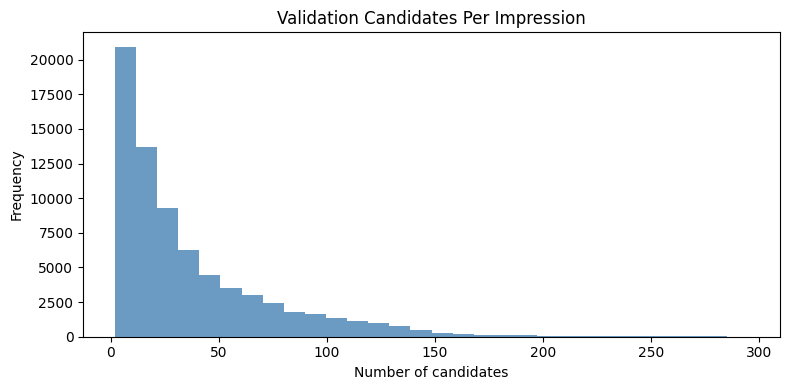

Saved files in: /Users/xiangningdeng/Desktop/2026 UCLA MDSH-Submit/round1_baselines/round1_descriptive_stats_output

Shape summary:


,table,rows,cols
0,news_train,51282,8
1,news_valid,42416,8
2,news_combined_unique,65238,8
3,behaviors_train,156965,5
4,behaviors_valid,73152,5



Candidate summary:


,split,impressions,candidates,avg_candidates_per_impression,ctr
0,train,156965,5843444,37.227688,0.040446
1,valid,73152,2740998,37.469898,0.040636



History summary:


,split,mean,median,p90,max
0,train,32.539987,19.0,78.0,558
1,valid,32.295959,19.0,78.0,444



Top categories:


,category,count
0,news,20039
1,sports,19368
2,finance,3786
3,foodanddrink,3123
4,travel,3013
5,lifestyle,2991
6,video,2712
7,weather,2601
8,health,2207
9,autos,2076


In [8]:
# History length statistics
beh_train_hist = beh_train.copy()
beh_valid_hist = beh_valid.copy()
beh_train_hist["history_len"] = beh_train_hist["history"].map(history_len)
beh_valid_hist["history_len"] = beh_valid_hist["history"].map(history_len)

history_summary = pd.DataFrame([
    {
        "split": "train",
        "mean": beh_train_hist["history_len"].mean(),
        "median": beh_train_hist["history_len"].median(),
        "p90": beh_train_hist["history_len"].quantile(0.9),
        "max": beh_train_hist["history_len"].max(),
    },
    {
        "split": "valid",
        "mean": beh_valid_hist["history_len"].mean(),
        "median": beh_valid_hist["history_len"].median(),
        "p90": beh_valid_hist["history_len"].quantile(0.9),
        "max": beh_valid_hist["history_len"].max(),
    },
])

# Category distribution from merged news table
category_top20 = (
    news_all["category"]
    .fillna("UNKNOWN")
    .value_counts()
    .rename_axis("category")
    .reset_index(name="count")
    .head(20)
)

# Missingness in key text fields
missing_summary = pd.DataFrame([
    {
        "field": col,
        "missing_count": int(news_all[col].isna().sum()),
        "missing_ratio": float(news_all[col].isna().mean()),
    }
    for col in ["title", "abstract", "category", "subcategory"]
])

# Save outputs
shape_summary.to_csv(OUTPUT_DIR / "shape_summary.csv", index=False)
candidate_summary.to_csv(OUTPUT_DIR / "candidate_summary.csv", index=False)
history_summary.to_csv(OUTPUT_DIR / "history_summary.csv", index=False)
category_top20.to_csv(OUTPUT_DIR / "category_top20.csv", index=False)
missing_summary.to_csv(OUTPUT_DIR / "missing_summary.csv", index=False)

with open(OUTPUT_DIR / "summary.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "seed": SEED,
            "train_candidates": int(len(train_candidates)),
            "valid_candidates": int(len(valid_candidates)),
            "train_ctr": float(train_candidates["label"].mean()),
            "valid_ctr": float(valid_candidates["label"].mean()),
            "news_combined_unique": int(len(news_all)),
            "valid_impressions": int(len(beh_valid)),
        },
        f,
        indent=2,
    )

# Plot candidate-per-impression distribution (valid)
valid_cand_count = (
    valid_candidates.groupby("impression_id")["candidate_news_id"]
    .count()
    .rename("num_candidates")
)

plt.figure(figsize=(8, 4))
plt.hist(valid_cand_count.values, bins=30, color="steelblue", alpha=0.8)
plt.title("Validation Candidates Per Impression")
plt.xlabel("Number of candidates")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "valid_candidates_per_impression.png", dpi=120)
plt.show()

print("Saved files in:", OUTPUT_DIR.resolve())
print("\nShape summary:")
display(shape_summary)
print("\nCandidate summary:")
display(candidate_summary)
print("\nHistory summary:")
display(history_summary)
print("\nTop categories:")
display(category_top20.head(10))

### Interpretation for Section 3 (Additional Statistics)

- User history is right-skewed (mean `~32.5`, median `19`, p90 `78`, max up to `558`), showing a clear long-tail of heavy users.
- Missingness is low in key structural fields (`title`, `category`, `subcategory`), while `abstract` has moderate missingness (`~5.23%`) and should be handled with fallback text.
- Category distribution is head-heavy (`news` and `sports` dominate) with a long tail of rare categories.
- This distribution pattern can mask subgroup behavior under aggregate metrics, so category-level breakdowns are useful in later rounds.

## 3.1) Extra Visualizations

Additional figures for report-ready descriptive analysis.

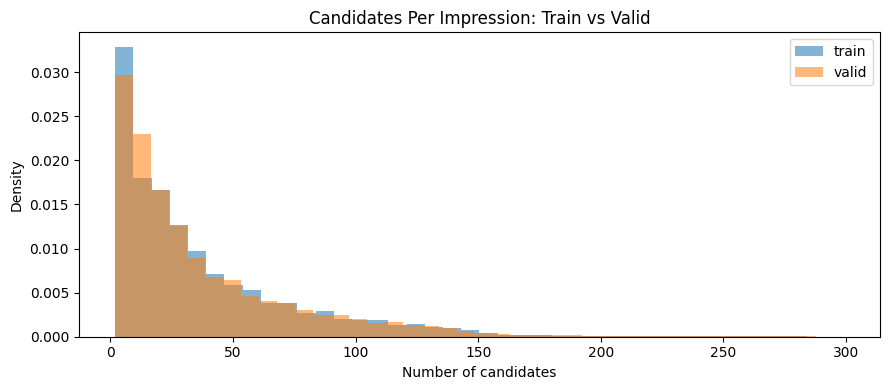

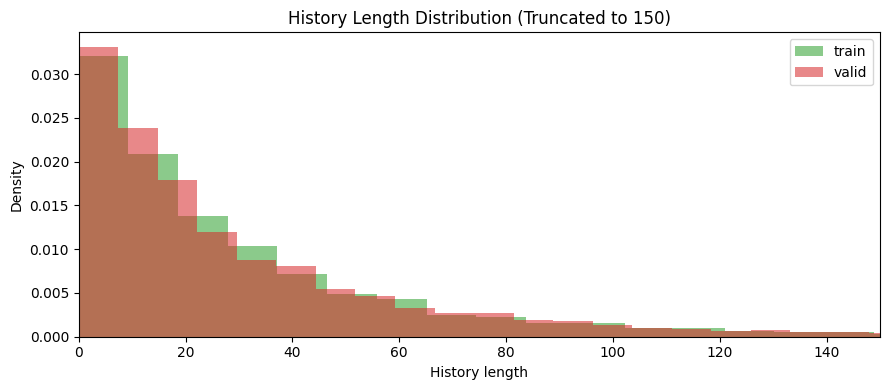

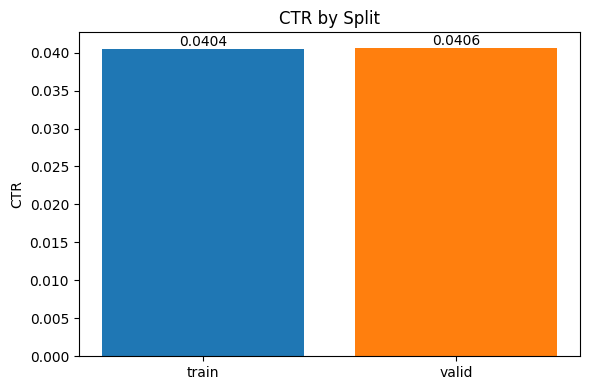

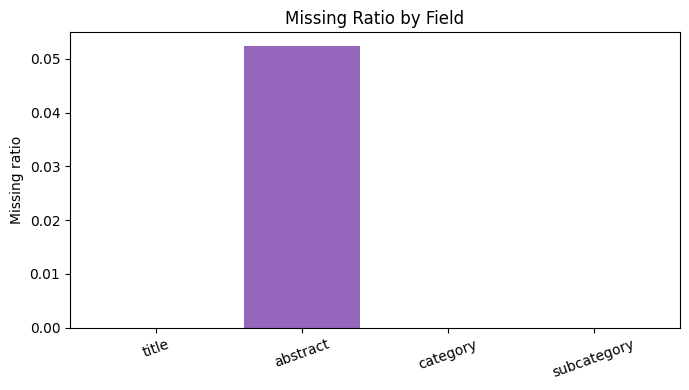

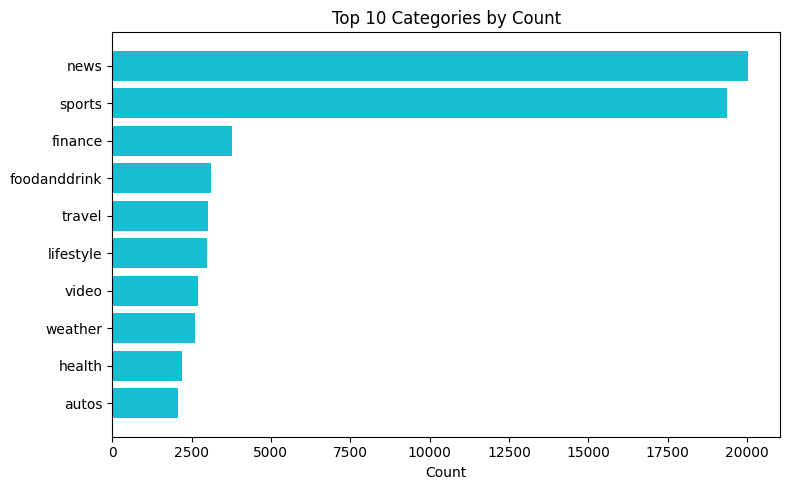

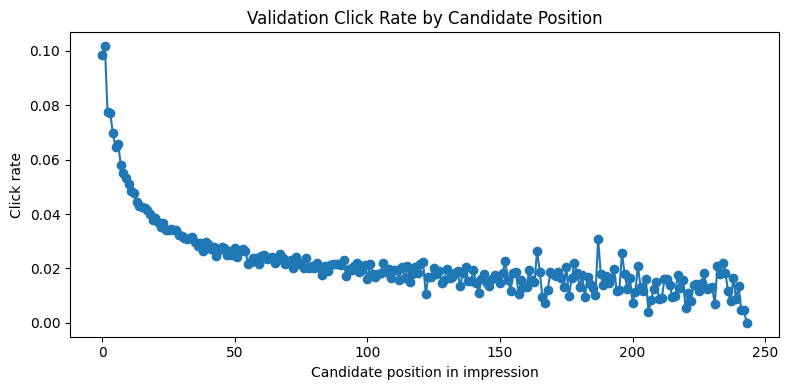

Extra figures saved in: /Users/xiangningdeng/Desktop/2026 UCLA MDSH-Submit/round1_baselines/round1_descriptive_stats_output


In [9]:
# Extra plots: save all to OUTPUT_DIR

# 1) Candidate count per impression: train vs valid
train_cand_count = train_candidates.groupby("impression_id")["candidate_news_id"].count()
valid_cand_count = valid_candidates.groupby("impression_id")["candidate_news_id"].count()

plt.figure(figsize=(9, 4))
plt.hist(train_cand_count.values, bins=40, alpha=0.55, label="train", color="tab:blue", density=True)
plt.hist(valid_cand_count.values, bins=40, alpha=0.55, label="valid", color="tab:orange", density=True)
plt.title("Candidates Per Impression: Train vs Valid")
plt.xlabel("Number of candidates")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "candidates_per_impression_train_vs_valid.png", dpi=120)
plt.show()

# 2) History length distribution: train vs valid
plt.figure(figsize=(9, 4))
plt.hist(beh_train_hist["history_len"], bins=60, alpha=0.55, label="train", color="tab:green", density=True)
plt.hist(beh_valid_hist["history_len"], bins=60, alpha=0.55, label="valid", color="tab:red", density=True)
plt.xlim(0, 150)
plt.title("History Length Distribution (Truncated to 150)")
plt.xlabel("History length")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "history_length_train_vs_valid.png", dpi=120)
plt.show()

# 3) CTR comparison bar chart
ctr_df = candidate_summary[["split", "ctr"]].copy()
plt.figure(figsize=(6, 4))
bars = plt.bar(ctr_df["split"], ctr_df["ctr"], color=["tab:blue", "tab:orange"])
plt.title("CTR by Split")
plt.ylabel("CTR")
for b in bars:
    h = b.get_height()
    plt.text(b.get_x() + b.get_width() / 2, h, f"{h:.4f}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ctr_by_split.png", dpi=120)
plt.show()

# 4) Missing ratio chart
plt.figure(figsize=(7, 4))
plt.bar(missing_summary["field"], missing_summary["missing_ratio"], color="tab:purple")
plt.title("Missing Ratio by Field")
plt.ylabel("Missing ratio")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "missing_ratio_by_field.png", dpi=120)
plt.show()

# 5) Top category share (top 10)
cat10 = category_top20.head(10).copy()
cat10["share"] = cat10["count"] / cat10["count"].sum()
plt.figure(figsize=(8, 5))
plt.barh(cat10["category"][::-1], cat10["count"][::-1], color="tab:cyan")
plt.title("Top 10 Categories by Count")
plt.xlabel("Count")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top10_categories_count.png", dpi=120)
plt.show()

# 6) Candidate position vs click rate (valid)
pos_ctr = valid_candidates.groupby("candidate_pos")["label"].agg(["mean", "count"]).reset_index()
pos_ctr = pos_ctr[pos_ctr["count"] >= 200]
plt.figure(figsize=(8, 4))
plt.plot(pos_ctr["candidate_pos"], pos_ctr["mean"], marker="o", linewidth=1.5)
plt.title("Validation Click Rate by Candidate Position")
plt.xlabel("Candidate position in impression")
plt.ylabel("Click rate")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "valid_click_rate_by_candidate_position.png", dpi=120)
plt.show()

print("Extra figures saved in:", OUTPUT_DIR.resolve())

### Interpretation for Extra Visualizations

- Train and validation have nearly overlapping candidate-count and history-length distributions, which supports split consistency.
- CTR remains low and stable across splits, reinforcing the sparse-click nature of the task.
- Missingness is concentrated in `abstract`; other core fields are essentially complete.
- Category frequency is strongly head-heavy, with a long tail of low-frequency categories.
- Click rate by candidate position can reveal presentation/order bias in impressions and is useful for debugging ranking behavior.

## 4) Note

All interpretation blocks are now placed immediately after their corresponding code chunks:
- Section 1 interpretation follows the data-loading code.
- Section 2 interpretation follows the candidate-expansion code.
- Section 3 interpretation follows the additional-statistics code.
- Extra visualization interpretation follows the extra-plot code.